# IRIS tutorial: time-lapse scRNA-seq

For this tutorial, we will use data from [A single-cell time-lapse of mouse prenatal development from gastrula to birth](https://doi.org/10.1038/s41586-024-07069-w). The authors sequence RNA from developing mouse embryos from day 8 to birth (day ~19), assign cell types, and group them into major cell clusters, which we will use for coloring. The whole notebook should take 5-10 minutes, depending on download speeds and number of cores available.

Requirements: `iris-learn`, `scanpy`, `colorcet`, `seaborn`

## Load data

For convenience, we'll use a prepared %1 subsample of '[whole data: normalized subset 1](https://cellxgene.cziscience.com/collections/45d5d2c3-bc28-4814-aed6-0bb6f0e11c82)', which will be 29k cells.

*This will take a few minutes.*

In [1]:
import urllib.request
import scanpy
import os

data_file = "qiu-29k_subset.h5ad"
if not os.path.exists(data_file):
	urllib.request.urlretrieve("https://osf.io/yd9mf/download", data_file)

adata = scanpy.read_h5ad(data_file)

## PCA reduction

In [2]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 48894981 stored elements and shape (28604, 45525)>

We can see that the data are fairly sparse, with about 4% nonzero elements. We can thus use PCA to linearly reduce to an intermediate number of dimensions for efficieny of final dimension reduction.

*This will take a few minutes.*

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=300)
X = pca.fit_transform(adata.X)

print(pca.explained_variance_ratio_.sum())

0.30142143


## Time formatting

In [4]:
adata.obs['author_day']

run_18_PD-11E_S373.AGATCGGATCCAGTCCTCT-7     E1425
run_19_PA-06F_S46.AACTGGCATTCGCTAAGCA-8      E1025
run_25_PA-10H_S80.TCGAATCTTTATATGAGCCA-14    P0000
run_23_PA-01A_S1.TCGTTCTGTTTCAAGACCA-12      E1875
run_17_PD-07F_S342.TCCAAGTTATTTGCGAGGCA-5    E0975
                                             ...  
run_15_PC-01B_S194.CAGCATTGTTGGAAGTACC-3     E0950
run_19_PD-09E_S357.GCTCGAGATTCAAGCCGAT-8     E1050
run_14_PZ-07D_S340.CTGATAGGTCCGATTCCTG-2     E1200
run_15_PC-10G_S271.CAACGCAGTTTATAAGAAC-3     E0950
run_19_PB-02H_S112.ACGTCTAGTGCCAACGCCA-8     E1075
Name: author_day, Length: 28604, dtype: category
Categories (43, object): ['E0800-E0850', 'E0875', 'E0900', 'E0925', ..., 'E1825', 'E1850', 'E1875', 'P0000']

As we can see, time is stored as strings of the fractional day times 100. We'll need to convert these to floating point days, handling some edge cases.

In [5]:
def format_day(day_str):
    if day_str == 'P0000': # birth series
        return 19.
    elif day_str == 'E0800-E0850':
        return 8.
    else:
        return float(day_str[1:])/100

t = adata.obs['author_day'].apply(format_day).to_numpy()
t

array([14.25, 10.25, 19.  , ..., 12.  ,  9.5 , 10.75])

## IRIS

We now have `X` and `t` and are ready to learn a layout.

*This will take a few minutes.*

In [6]:
from IRIS import fit_transform

lay = fit_transform(X, t)

Optimal rho: -1.24
Building ANNOY index with 32 trees ......
 Done with 28604 points in index.
Querying ANN index with 32 neighbors ......100% Done.
Test knn accuracy : 82.84%
Running propagation 3/3
Test knn accuracy : 99.28%
Computing similarities ...... Done.
Fitting model	Alpha: 0.000021	Progress: 99.979%


## Plotting

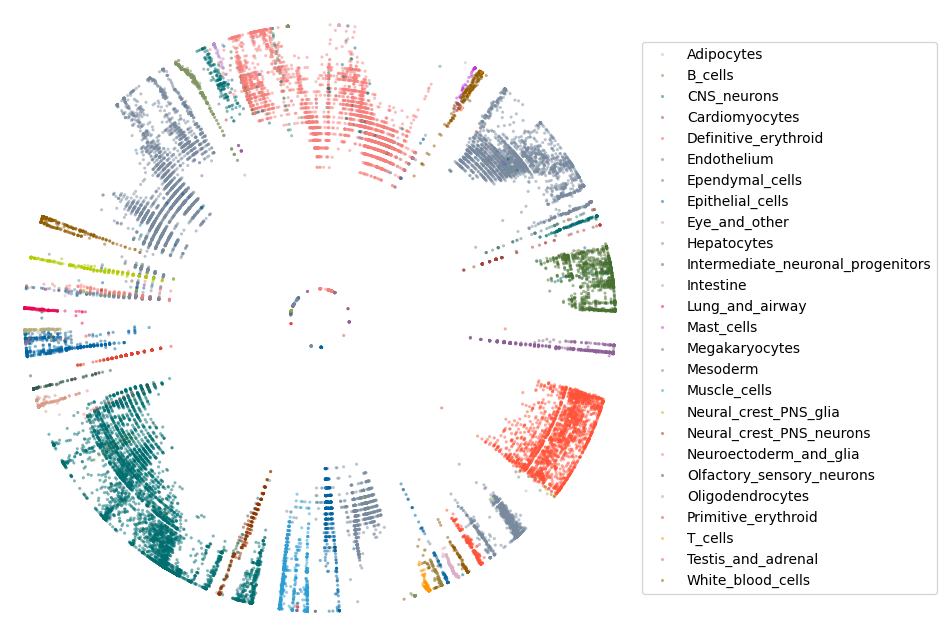

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import colorcet as cc
import matplotlib as mpl

def plot_iris(adata, lay, label_field = 'author_major_cell_cluster'):
	adata.obs['x'] = lay[:,0]
	adata.obs['y'] = lay[:,1]

	palette = sns.color_palette(reversed(list((cc.glasbey_dark))), n_colors=adata.obs[label_field].nunique())
	plt.figure(figsize=(8,8))
	ax = sns.scatterplot(x="x", y="y",
						hue=label_field, palette=palette,
						s=5, data=adata.obs.sample(frac=1, random_state=1), alpha=.5, edgecolor='none')

	# clean up the plot
	sns.despine(left=True, bottom=True, top=True, right=True)
	plt.xticks(ticks=[], labels=[])
	plt.yticks(ticks=[], labels=[])
	plt.xlim(-105, 105)
	plt.ylim(-105, 105)
	ax.set(xlabel=None, ylabel=None)

	legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

	plt.show()

plot_iris(adata, lay)

## Time resampling

This is a great start, but we can see that the sparsity of time values is causing crowding. Let's resample, using `sample_time='hetero'` because our intervals are not even. We can also manually adjust `rho` to make the compression to the outer rings a little less extreme than the automatically chosen value of `-1.24`.

*This will take a few minutes.*

Building ANNOY index with 32 trees ......
 Done with 28604 points in index.
Querying ANN index with 32 neighbors ......100% Done.
Test knn accuracy : 84.19%
Running propagation 3/3
Test knn accuracy : 99.38%
Computing similarities ...... Done.
Fitting model	Alpha: 0.000021	Progress: 99.979%


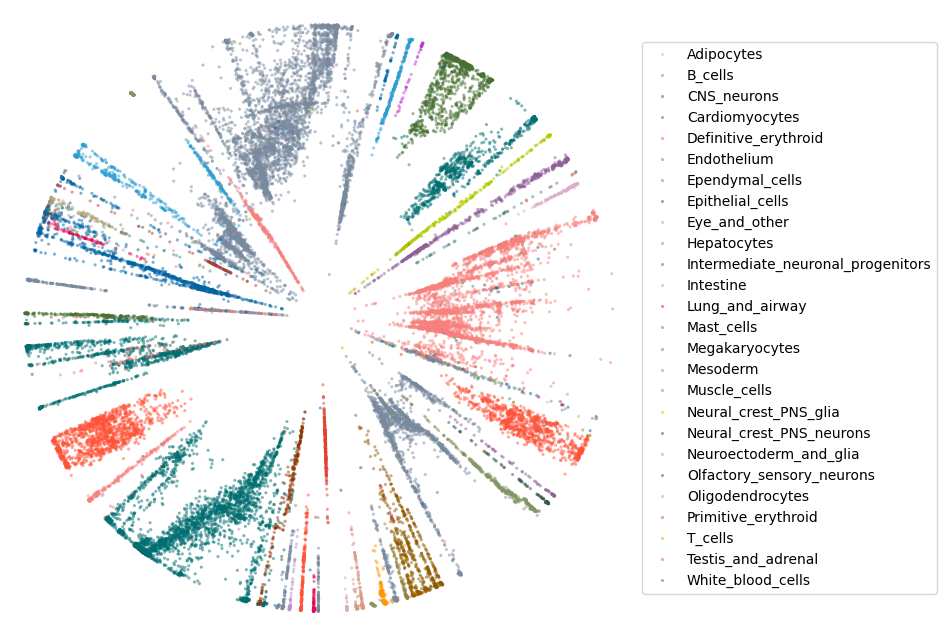

In [8]:
lay = fit_transform(X, t,
	sample_time='hetero',
	rho=-.5
)
plot_iris(adata, lay)

## Advanced plotting

It would be nice to see some reference rings for time. To do that, we'll need to get polar coordinates from `fit_transform`. We'll also explicitly set `zeta` so we know its value later.

*This will take a few minutes.*

In [9]:
zeta = 0.1
rho = -0.5
lay = fit_transform(X, t,
	sample_time='hetero',
	rho=rho,
	zeta=zeta,
	return_polar=True,
)

Building ANNOY index with 32 trees ......
 Done with 28604 points in index.
Querying ANN index with 32 neighbors ......100% Done.
Test knn accuracy : 85.16%
Running propagation 3/3
Test knn accuracy : 99.50%
Computing similarities ...... Done.
Fitting model	Alpha: 0.000018	Progress: 99.982%


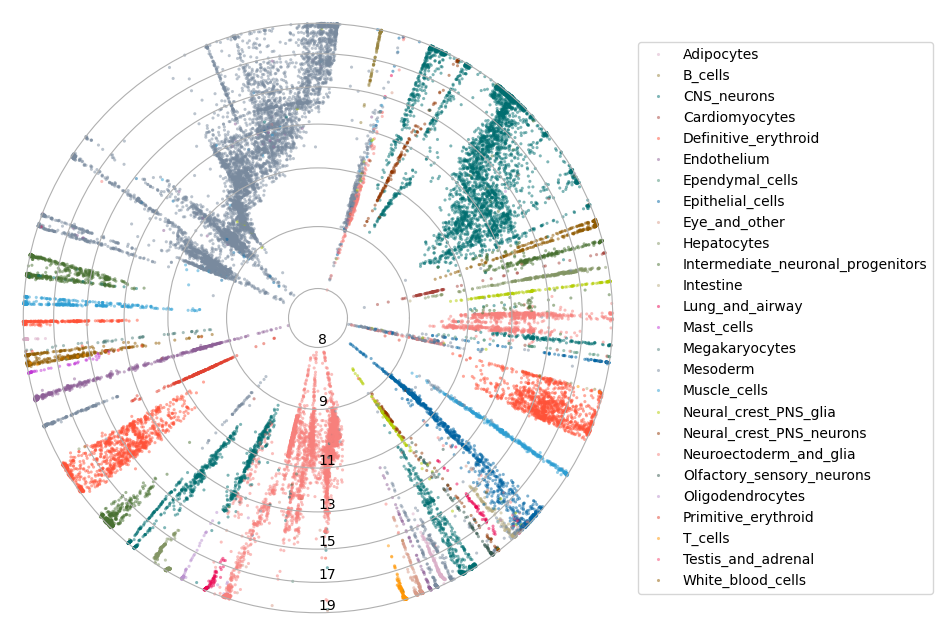

In [15]:
import numpy as np
power_norm = np.exp(-.5)

def plot_iris_polar(adata, lay, t, zeta, rho, tick_vals, tick_angle=30, label_field = 'author_major_cell_cluster'):
	adata.obs['r'] = lay[:, 0]
	adata.obs['theta'] = lay[:, 1]

	fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,8))
	palette = sns.color_palette(reversed(list((cc.glasbey_dark))), n_colors=adata.obs[label_field].nunique())

	sns.scatterplot(
		x="theta", y="r", ax=ax,
		hue=label_field, palette=palette,
		s=5, data=adata.obs.sample(frac=1, random_state=1), alpha=.5, edgecolor='none'
	)
	
	# transform the tick values
	tick_vals_tfm = zeta + (1-zeta)*((tick_vals-t.min())/(t.max()-t.min()))**np.exp(rho)
	ax.set_yticks(tick_vals_tfm)
	ax.set_yticklabels(tick_vals)

	# clean up the plot
	ax.set_xticks([])  # Hide angular ticks
	ax.spines['polar'].set_visible(False)
	ax.set(xlabel=None, ylabel=None)
	ax.set_rlabel_position(tick_angle)

	legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

	plt.show()

plot_iris_polar(adata, lay, t,
	0.1, # zeta
	-.5, # rho
	[8, 9, 11, 13, 15, 17, 19], # tick_vals
	tick_angle=270
)
